# Linear Regression: Potential problems 

Due to the nature of the engineered dataset, collinearity will likely appear. We have to diagnose our models

In [1]:
import sys
sys.path.append("..")
from src.models.regression.diagnostics import run_regression_diagnostics
import pandas as pd

df_processed = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

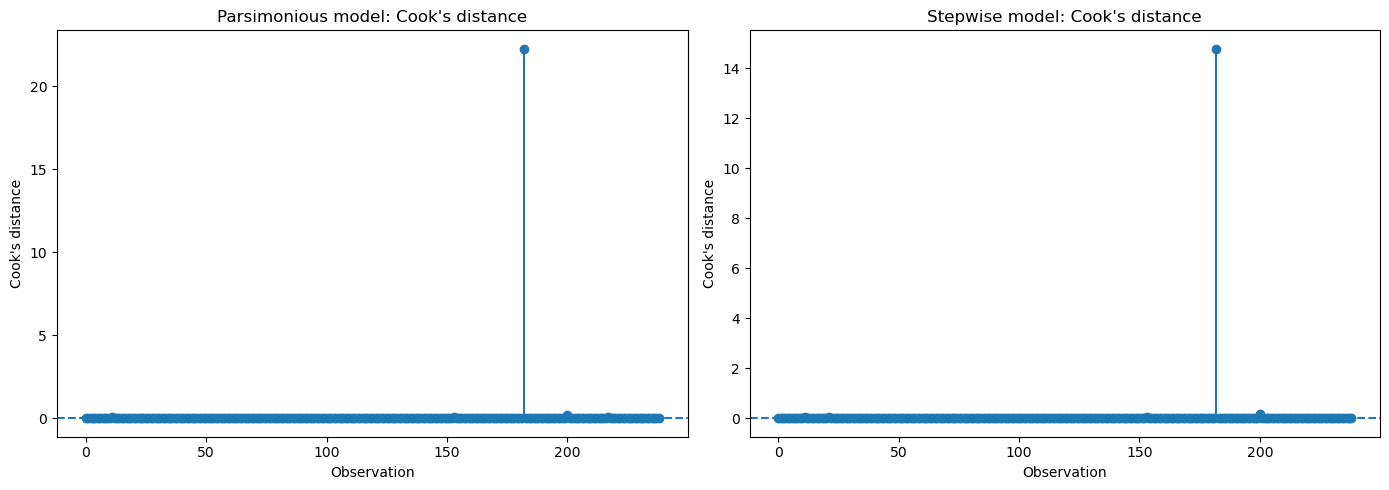

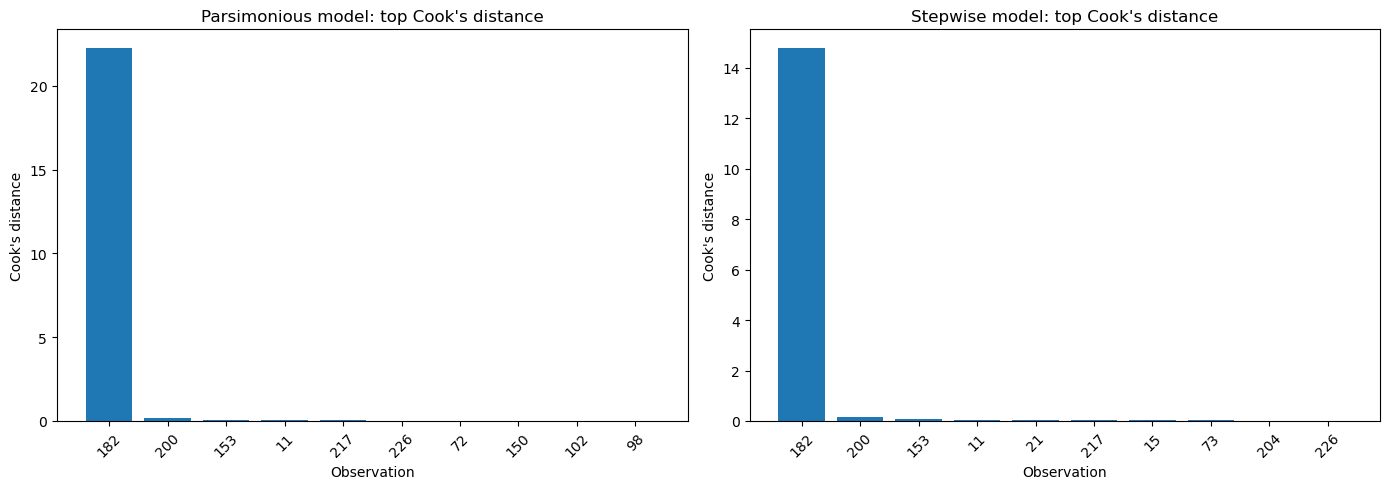

,feature,vif
0,ejection_creatinine_interaction,3.177476
1,creatinine_log,20.448147
2,sodium_creatinine_interaction,14.010282


,feature,vif
0,age_centered,1.072863
1,creatinine_log,20.559904
2,ejection_creatinine_interaction,3.206959
3,sodium_creatinine_interaction,14.825516
4,serum_sodium,1.238498


,model,bp_stat,bp_pvalue,f_stat,f_pvalue
0,parsimonious,122.635227,2.088553e-26,82.554418,1.651845e-36
1,stepwise,121.001487,1.925698e-24,47.785935,6.839870e-34


,model,n_observations,cooks_threshold_4_over_n,n_influential_points,max_cooks_distance
0,parsimonious,239,0.016736,8,22.248144
1,stepwise,239,0.016736,10,14.779445


In [2]:
results = run_regression_diagnostics(
    df_processed,
    parsimonious_features=[
        "ejection_creatinine_interaction",
        "creatinine_log",
        "sodium_creatinine_interaction",
    ],
    stepwise_features=[
        "age_centered",
        "creatinine_log",
        "ejection_creatinine_interaction",
        "sodium_creatinine_interaction",
        "serum_sodium",
    ],
)

display(results["parsimonious"]["vif_table"])
display(results["stepwise"]["vif_table"])

display(results["heteroscedasticity_table"])
display(results["influential_summary_table"])

Model diagnostics reveal several common issues in clinical regression
models.

Variance inflation factors indicate the presence of multicollinearity,
particularly among predictors derived from creatinine measurements.
This is expected given the use of interaction terms and transformed
variables.

The Breusch–Pagan test strongly suggests heteroscedasticity, indicating
that the variance of residuals is not constant across the range of
fitted values.

Cook's distance analysis identifies a small number of influential
observations, likely corresponding to patients with extreme clinical
measurements.

Despite these issues, the models remain useful for predictive purposes,
as these violations primarily affect inference rather than predictive
performance.